# Trimmed Mean PCE Nowcast from CPI and PPI

Once CPI (~mid-month) and PPI (~1 day later) are released for a month, the official
Trimmed Mean PCE for that month is still ~2 weeks away (PCE prints near month-end).
This notebook estimates it early:

1. Each of the 178 trimmed-mean PCE components is mapped to the CPI or PPI series BEA
   uses as its deflator (NIPA Handbook, Chapter 5). Most goods and housing map to
   detailed CPI items; physician/hospital/nursing services, airfares, insurance, and
   portfolio management map to PPIs.
2. Components with no timely monthly source (imputed bank services, pensions, life
   insurance, NPISH, etc.) are assumed to repeat their **trailing 6-month average**
   BEA-published change.
3. The estimated component changes are run through the Dallas Fed's weighted trim
   (lower 24% / upper 31% of expenditure weight) using the prior month's weights.
4. The nowcast is backtested monthly from 2015 against the actual Dallas Fed series
   (FRED `PCETRIM1M158SFRBDAL`).

Data sources: BLS API v2 (CPI/PPI), BEA API (underlying detail tables U20404/U20405/U20406
for weights, fallbacks, and component-level actuals), FRED (official trimmed mean).

In [1]:
import json
import time
import urllib.parse
import urllib.request
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLS_API_KEY = "52fd9616f3bc44a3878d8416229082ca"
FRED_API_KEY = "51f3ac7bc8b65cb6bb2589fc570292be"
BEA_API_KEY = "FD4E7F46-5D89-4CA8-BE48-4F5997F83B3B"

BASE_DIR = Path.cwd()
COMPONENT_FILE = BASE_DIR / "Trimmed_Mean_Components.xlsx"
OUTPUT_DIR = BASE_DIR / "outputs"

LOWER_TRIM = 0.24
UPPER_TRIM = 0.31
RETAINED_MASS = 1.0 - LOWER_TRIM - UPPER_TRIM

BACKTEST_START = pd.Timestamp("2015-01-01")  # first backtest month
SOURCE_START_YEAR = 2009  # CPI/PPI pull start (5y history feeds the crude SA)
BEA_START_YEAR = 2013     # BEA pull start (weights, fallbacks, backtest actuals)
CRUDE_SA = True           # crude own-history seasonal adjustment of NSA series

## 1. Load Trimmed Mean Components

The workbook lists the 178 BEA underlying-detail line items (table U20404) that enter
the Dallas Fed trimmed mean. Line 156 is also pulled from BEA because lines 157/158
(tenant rent) are merged into it after 2001.

In [2]:
components = pd.read_excel(COMPONENT_FILE, usecols=[0, 1, 2])
components.columns = ["line_item", "description", "code"]
components = components.dropna(subset=["line_item"]).copy()
components["line_item"] = components["line_item"].astype(int)
components["description"] = components["description"].astype(str).str.strip()
components = components.sort_values("line_item").reset_index(drop=True)

component_lines = components["line_item"].tolist()
bea_lines = sorted(set(component_lines + [156]))
print(len(component_lines), "components")

178 components


## 2. CPI/PPI Crosswalk

Maps each component line to its source series, following the BEA NIPA Handbook Ch. 5
deflator assignments (validated against actual BEA component price changes, 2015-2025):

- `CUSR0000...` = seasonally adjusted CPI, `CUUR0000...` = NSA CPI,
  `PCU.../WPU...` = PPI (NSA). NSA series get a crude seasonal adjustment below.
- Composites (e.g. communication, paramedical) average several series with fixed weights.
- `"NONE"` = no timely monthly source (imputed/input-cost items, discontinued CPI series,
  or cases where the trailing-average fallback empirically fits BEA better). These use
  the trailing 6-month average of the component's own BEA-published change.

In [3]:
CROSSWALK = {
    # --- Motor vehicles and parts ---
    7:   ("CPI", {"CUSR0000SETA01": 1.0}),   # New domestic autos -> new vehicles
    8:   ("CPI", {"CUSR0000SETA01": 1.0}),   # New foreign autos -> new vehicles
    9:   ("CPI", {"CUSR0000SS45021": 1.0}),  # New light trucks -> new trucks
    13:  ("CPI", {"CUSR0000SETA02": 1.0}),   # Used autos -> used cars and trucks
    17:  ("CPI", {"CUSR0000SETA02": 1.0}),   # Used light trucks
    21:  ("CPI", {"CUSR0000SETC01": 1.0}),   # Tires
    22:  ("CPI", {"CUUR0000SETC02": 1.0}),   # Accessories and parts
    # --- Furnishings and durable household equipment ---
    25:  ("CPI", {"CUSR0000SEHJ": 1.0}),     # Furniture -> furniture and bedding
    26:  ("CPI", {"CUUR0000SEHL01": 1.0}),   # Clocks, lamps, decorator items
    27:  ("CPI", {"CUUR0000SEHH01": 1.0}),   # Carpets -> floor coverings
    28:  ("CPI", {"CUSR0000SEHH02": 1.0}),   # Window coverings
    30:  ("CPI", {"CUSR0000SEHK01": 1.0}),   # Major household appliances
    31:  ("CPI", {"CUSR0000SEHK02": 1.0}),   # Small electric appliances -> other appliances
    33:  ("NONE", {}),                       # Dishes and flatware (fallback fits better)
    34:  ("NONE", {}),                       # Nonelectric cookware (fallback fits better)
    36:  ("CPI", {"CUSR0000SEHM01": 1.0}),   # Tools, hardware and supplies
    37:  ("CPI", {"CUSR0000SEHM02": 1.0}),   # Outdoor equipment and supplies
    # --- Recreational goods and vehicles ---
    41:  ("CPI", {"CUSR0000SERA01": 1.0}),   # Televisions
    42:  ("CPI", {"CUSR0000SERA03": 1.0}),   # Other video equipment
    43:  ("CPI", {"CUSR0000SERA05": 1.0}),   # Audio equipment
    45:  ("CPI", {"CUUR0000SERA06": 1.0}),   # Audio media -> recorded music
    46:  ("CPI", {"CUUR0000SERA04": 1.0}),   # Video media
    47:  ("CPI", {"CUSR0000SERD01": 1.0}),   # Photographic equipment
    49:  ("CPI", {"CUSR0000SEEE01": 1.0}),   # Personal computers and peripherals
    50:  ("CPI", {"CUUR0000SEEE02": 1.0}),   # Computer software and accessories
    51:  ("CPI", {"CUSR0000SEEE04": 1.0}),   # Calculators/other info processing
    52:  ("CPI", {"CUSR0000SERC02": 1.0}),   # Sporting equipment -> sports equipment
    54:  ("CPI", {"CUSR0000SERC01": 1.0}),   # Motorcycles -> sports vehicles incl bicycles
    55:  ("CPI", {"CUSR0000SERC01": 1.0}),   # Bicycles
    57:  ("CPI", {"CUSR0000SERC01": 1.0}),   # Pleasure boats
    58:  ("CPI", {"CUSR0000SERC01": 1.0}),   # Pleasure aircraft
    59:  ("CPI", {"CUSR0000SERC01": 1.0}),   # Other recreational vehicles
    60:  ("CPI", {"CUUR0000SERG02": 1.0}),   # Recreational books
    61:  ("CPI", {"CUSR0000SERE03": 1.0}),   # Musical instruments
    64:  ("CPI", {"CUSR0000SEAG02": 1.0}),   # Jewelry
    65:  ("CPI", {"CUSR0000SEAG01": 1.0}),   # Watches
    # --- Other durable goods ---
    67:  ("CPI", {"CUUR0000SEMG": 1.0}),     # Therapeutic medical equipment
    68:  ("CPI", {"CUSR0000SEMC04": 1.0}),   # Eyeglasses and eye care
    69:  ("CPI", {"CUSR0000SEEA": 1.0}),     # Educational books and supplies
    70:  ("CPI", {"CUSR0000SEGE": 1.0}),     # Luggage -> misc personal goods
    71:  ("CPI", {"CUSR0000SEEE04": 1.0}),   # Telephone equipment
    # --- Food at home ---
    77:  ("CPI", {"CUSR0000SEFA": 1.0}),     # Cereals
    78:  ("CPI", {"CUSR0000SEFB": 1.0}),     # Bakery products
    80:  ("CPI", {"CUSR0000SEFC": 1.0}),     # Beef and veal
    81:  ("CPI", {"CUSR0000SEFD": 1.0}),     # Pork
    82:  ("CPI", {"CUSR0000SEFE": 1.0}),     # Other meats
    83:  ("CPI", {"CUSR0000SEFF": 1.0}),     # Poultry
    84:  ("CPI", {"CUSR0000SEFG": 1.0}),     # Fish and seafood
    86:  ("CPI", {"CUSR0000SEFJ01": 1.0}),   # Fresh milk -> milk
    87:  ("CPI", {"CUSR0000SEFJ": 1.0}),     # Processed dairy -> dairy products
    88:  ("CPI", {"CUSR0000SEFH": 1.0}),     # Eggs
    89:  ("CPI", {"CUSR0000SEFS": 1.0}),     # Fats and oils
    91:  ("CPI", {"CUSR0000SEFK": 1.0}),     # Fresh fruit
    92:  ("CPI", {"CUSR0000SEFL": 1.0}),     # Fresh vegetables
    93:  ("CPI", {"CUSR0000SEFM": 1.0}),     # Processed fruits and vegetables
    94:  ("CPI", {"CUSR0000SEFR": 1.0}),     # Sugar and sweets
    95:  ("CPI", {"CUSR0000SEFT": 1.0}),     # Food nec -> other foods
    97:  ("CPI", {"CUSR0000SEFP": 1.0}),     # Coffee, tea -> beverage materials
    98:  ("CPI", {"CUSR0000SEFN": 1.0}),     # Soft drinks -> nonalcoholic beverages
    100: ("CPI", {"CUSR0000SEFW02": 1.0}),   # Spirits at home
    101: ("CPI", {"CUSR0000SEFW03": 1.0}),   # Wine at home
    102: ("CPI", {"CUSR0000SEFW01": 1.0}),   # Beer at home
    103: ("NONE", {}),                       # Food produced/consumed on farms
    # --- Clothing and footwear ---
    106: ("CPI", {"CUSR0000SEAC": 1.0}),     # Women's and girls'
    107: ("CPI", {"CUSR0000SEAA": 1.0}),     # Men's and boys'
    108: ("CPI", {"CUSR0000SEAF": 1.0}),     # Children's and infants'
    110: ("NONE", {}),                       # Clothing materials (no live CPI series)
    111: ("NONE", {}),                       # Military clothing
    112: ("CPI", {"CUSR0000SEAE": 1.0}),     # Footwear
    # --- Energy goods ---
    115: ("CPI", {"CUSR0000SETB01": 1.0}),   # Gasoline
    116: ("CPI", {"CUUR0000SS47021": 1.0}),  # Lubricants -> motor oil, coolant
    118: ("CPI", {"CUSR0000SEHE01": 1.0}),   # Fuel oil
    119: ("CPI", {"CUSR0000SEHE02": 1.0}),   # Other fuels -> propane, kerosene, firewood
    # --- Medical goods ---
    123: ("CPI", {"CUSR0000SEMF01": 1.0}),   # Prescription drugs
    124: ("CPI", {"CUSR0000SEMF02": 1.0}),   # Nonprescription drugs
    125: ("CPI", {"CUUR0000SEMG": 1.0}),     # Other medical products
    # --- Other nondurable goods ---
    127: ("CPI", {"CUSR0000SERE01": 1.0}),   # Games, toys -> toys
    128: ("CPI", {"CUSR0000SERB01": 1.0}),   # Pets and related products
    129: ("CPI", {"CUSR0000SEHL02": 1.0}),   # Flowers, seeds, potted plants
    130: ("CPI", {"CUUR0000SERD02": 1.0}),   # Film and photographic supplies
    132: ("CPI", {"CUSR0000SEHN01": 1.0}),   # Household cleaning products
    133: ("CPI", {"CUUR0000SEHN02": 1.0}),   # Household paper products
    134: ("CPI", {"CUSR0000SEHH03": 1.0}),   # Household linens -> other linens
    135: ("NONE", {}),                       # Sewing items (no live CPI series)
    136: ("CPI", {"CUSR0000SEHN03": 1.0}),   # Misc household products
    138: ("CPI", {"CUUR0000SEGB01": 1.0}),   # Hair/dental/shaving products
    139: ("CPI", {"CUUR0000SEGB02": 1.0}),   # Cosmetics
    140: ("NONE", {}),                       # Electric personal care (fallback fits better)
    141: ("CPI", {"CUSR0000SEGA": 1.0}),     # Tobacco
    143: ("CPI", {"CUUR0000SERG01": 1.0}),   # Newspapers and periodicals
    144: ("CPI", {"CUSR0000SEGE": 1.0}),     # Stationery -> misc personal goods
    # --- Housing ---
    155: ("CPI", {"CUSR0000SEHA": 1.0}),     # Tenant mobile homes -> rent
    157: ("CPI", {"CUSR0000SEHA": 1.0}),     # Tenant stationary homes -> rent
    158: ("CPI", {"CUSR0000SEHA": 1.0}),     # Tenant landlord durables -> rent
    161: ("CPI", {"CUSR0000SEHC": 1.0}),     # Owner mobile homes -> OER
    162: ("CPI", {"CUSR0000SEHC": 1.0}),     # Owner stationary homes -> OER
    163: ("NONE", {}),                       # Farm dwellings
    164: ("NONE", {}),                       # Group housing
    # --- Household utilities ---
    167: ("CPI", {"CUSR0000SEHG01": 1.0}),   # Water and sewer
    168: ("CPI", {"CUSR0000SEHG02": 1.0}),   # Garbage and trash
    170: ("CPI", {"CUSR0000SEHF01": 1.0}),   # Electricity
    171: ("CPI", {"CUSR0000SEHF02": 1.0}),   # Natural gas
    # --- Health care services (PPI per BEA methodology) ---
    174: ("PPI", {"PCU621111621111": 1.0}),  # Physician services
    175: ("CPI", {"CUSR0000SEMC02": 1.0}),   # Dental services (CPI fits BEA best)
    176: ("PPI", {"PCU621610621610": 0.5,    # Paramedical: home health
                  "PCU621511621511": 0.5}),  #   + medical labs
    184: ("PPI", {"PCU622110622110": 1.0}),  # Nonprofit hospitals
    185: ("PPI", {"PCU622110622110": 1.0}),  # Proprietary hospitals
    186: ("PPI", {"PCU622110622110": 1.0}),  # Government hospitals
    187: ("PPI", {"PCU623110623110": 1.0}),  # Nursing homes
    # --- Transportation services ---
    192: ("CPI", {"CUSR0000SETD": 1.0}),     # Motor vehicle maintenance/repair
    194: ("CPI", {"CUSR0000SETA03": 1.0}),   # Motor vehicle leasing -> leased cars
    197: ("CPI", {"CUSR0000SETA04": 1.0}),   # Motor vehicle rental -> car rental
    198: ("CPI", {"CUSR0000SS52051": 1.0}),  # Parking fees and tolls
    201: ("CPI", {"CUSR0000SETG02": 1.0}),   # Railway -> other intercity transport
    203: ("CPI", {"CUSR0000SETG02": 1.0}),   # Intercity buses
    204: ("NONE", {}),                       # Taxis (CPI series ended 2019)
    205: ("CPI", {"CUUR0000SETG03": 1.0}),   # Intracity mass transit
    206: ("NONE", {}),                       # Other road transportation
    207: ("PPI", {"PCU481111481111": 1.0}),  # Air transportation (PPI per BEA)
    208: ("CPI", {"CUSR0000SS53023": 1.0}),  # Water transportation -> ship fare
    # --- Recreation services ---
    211: ("CPI", {"CUSR0000SERF01": 1.0}),   # Membership clubs, sports centers
    212: ("CPI", {"CUSR0000SERF02": 1.0}),   # Amusement parks -> admissions
    214: ("CPI", {"CUSR0000SS62031": 1.0}),  # Movie theaters
    215: ("CPI", {"CUSR0000SS62031": 1.0}),  # Live entertainment
    216: ("NONE", {}),                       # Spectator sports (fallback fits better)
    217: ("NONE", {}),                       # Museums and libraries
    218: ("CPI", {"CUSR0000SERA02": 1.0}),   # AV services -> cable/satellite/streaming
    227: ("NONE", {}),                       # Casino gambling
    228: ("NONE", {}),                       # Lotteries
    229: ("NONE", {}),                       # Pari-mutuel
    231: ("CPI", {"CUSR0000SERB02": 1.0}),   # Veterinary and pet services
    232: ("NONE", {}),                       # Package tours
    233: ("NONE", {}),                       # Repair of rec vehicles/equipment
    # --- Food services and accommodations ---
    239: ("NONE", {}),                       # Elem/secondary school lunches (no CPI fit)
    240: ("NONE", {}),                       # Higher ed school lunches (no CPI fit)
    241: ("CPI", {"CUSR0000SEFV": 1.0}),     # Other purchased meals -> food away
    245: ("CPI", {"CUSR0000SEFX": 1.0}),     # Alcohol in purchased meals
    247: ("NONE", {}),                       # Food supplied to civilians
    248: ("NONE", {}),                       # Food supplied to military
    250: ("CPI", {"CUSR0000SEHB02": 1.0}),   # Hotels and motels
    251: ("CPI", {"CUSR0000SEHB01": 1.0}),   # Housing at schools
    # --- Financial services and insurance ---
    255: ("NONE", {}),                       # Commercial banks (imputed)
    256: ("NONE", {}),                       # Other depository (imputed)
    257: ("NONE", {}),                       # Pension funds (imputed)
    258: ("PPI", {"PCU5239405239401": 0.6,   # Financial charges: portfolio mgmt
                  "WPU40110101": 0.4}),      #   + brokerage/investment advice PPI
    271: ("NONE", {}),                       # Life insurance (imputed)
    272: ("PPI", {"PCU9241269241262": 1.0}), # Household insurance -> homeowners PPI
    275: ("PPI", {"PCU524114524114": 1.0}),  # Health insurance -> direct health PPI
    279: ("PPI", {"PCU9241269241261": 1.0}), # Motor vehicle insurance -> auto PPI
    # --- Communication ---
    281: ("CPI", {"CUUR0000SEED": 0.6,       # Telephone services
                  "CUSR0000SEEE03": 0.3,     # Internet services
                  "CUSR0000SEEC01": 0.1}),   # Postage
    # --- Education ---
    292: ("CPI", {"CUSR0000SEEB01": 1.0}),   # Public/proprietary higher ed -> college tuition
    293: ("CPI", {"CUSR0000SEEB01": 1.0}),   # Nonprofit higher ed
    295: ("CPI", {"CUSR0000SEEB02": 1.0}),   # Elementary and secondary schools
    296: ("CPI", {"CUSR0000SEEB03": 1.0}),   # Day care and nursery -> day care/preschool
    297: ("CPI", {"CUSR0000SEEB04": 1.0}),   # Commercial/vocational schools
    # --- Professional and personal services ---
    299: ("CPI", {"CUSR0000SEGD01": 1.0}),   # Legal services (ends 2025 -> fallback)
    301: ("NONE", {}),                       # Tax preparation (fallback fits better)
    302: ("NONE", {}),                       # Employment agency services
    303: ("NONE", {}),                       # Other personal business services
    304: ("NONE", {}),                       # Labor organization dues
    305: ("NONE", {}),                       # Professional association dues
    306: ("CPI", {"CUSR0000SEGD02": 1.0}),   # Funeral and burial
    309: ("CPI", {"CUUR0000SEGC01": 1.0}),   # Hairdressing -> haircuts
    310: ("CPI", {"CUUR0000SEGC": 1.0}),     # Misc personal care services
    312: ("CPI", {"CUSR0000SEGD03": 1.0}),   # Laundry and dry cleaning
    313: ("CPI", {"CUUR0000SEGD04": 1.0}),   # Clothing repair/rental
    314: ("CPI", {"CUUR0000SEGD04": 1.0}),   # Footwear repair
    316: ("CPI", {"CUSR0000SEEB03": 1.0}),   # Child care -> day care/preschool
    317: ("NONE", {}),                       # Social assistance
    324: ("NONE", {}),                       # Social advocacy orgs
    325: ("NONE", {}),                       # Religious organizations
    326: ("NONE", {}),                       # Foundations
    # --- Household services ---
    328: ("CPI", {"CUUR0000SEHP01": 1.0}),   # Domestic services (ends 2025 -> fallback)
    329: ("CPI", {"CUSR0000SEHP03": 1.0}),   # Moving, storage, freight
    330: ("CPI", {"CUUR0000SEHP04": 1.0}),   # Repair of furniture (ends 2025)
    331: ("CPI", {"CUUR0000SEHP04": 1.0}),   # Repair of appliances (ends 2025)
    332: ("NONE", {}),                       # Other household services
    # --- NPISH ---
    342: ("NONE", {}),                       # NPISH final consumption (imputed)
}


assert set(CROSSWALK) == set(component_lines), "crosswalk must cover every component"
n_none = sum(1 for s, _ in CROSSWALK.values() if s == "NONE")
print(f"{len(CROSSWALK)} lines mapped: {len(CROSSWALK) - n_none} to CPI/PPI, {n_none} to fallback")

178 lines mapped: 141 to CPI/PPI, 37 to fallback


## 3. Fetch Helpers

In [4]:
def bls_fetch(series_ids, start_year, end_year):
    """Fetch monthly BLS series (chunks of 50). Returns wide DataFrame + missing ids."""
    frames = {}
    series_ids = list(series_ids)
    for i in range(0, len(series_ids), 50):
        chunk = series_ids[i:i + 50]
        payload = json.dumps({
            "seriesid": chunk,
            "startyear": str(start_year),
            "endyear": str(end_year),
            "registrationkey": BLS_API_KEY,
        }).encode()
        req = urllib.request.Request(
            "https://api.bls.gov/publicAPI/v2/timeseries/data/",
            data=payload, headers={"Content-Type": "application/json"})
        with urllib.request.urlopen(req, timeout=120) as resp:
            out = json.loads(resp.read())
        if out.get("status") != "REQUEST_SUCCEEDED":
            raise RuntimeError(f"BLS API: {out.get('status')} {out.get('message')}")
        for s in out["Results"]["series"]:
            rows = {
                pd.Timestamp(int(r["year"]), int(r["period"][1:]), 1): float(r["value"])
                for r in s["data"]
                if r["period"].startswith("M") and r["period"] != "M13"
                and r["value"] not in ("-", "")
            }
            if rows:
                frames[s["seriesID"]] = pd.Series(rows)
        time.sleep(0.2)
    df = pd.DataFrame(frames).sort_index()
    missing = [sid for sid in series_ids if sid not in df.columns]
    return df, missing


def fred_fetch(series_id, start="2009-01-01"):
    """Fetch one FRED series as a monthly Series."""
    url = ("https://api.stlouisfed.org/fred/series/observations"
           f"?series_id={series_id}&api_key={FRED_API_KEY}&file_type=json"
           f"&observation_start={start}")
    with urllib.request.urlopen(url, timeout=60) as resp:
        obs = json.loads(resp.read())["observations"]
    return pd.Series({pd.Timestamp(o["date"]): float(o["value"])
                      for o in obs if o["value"] != "."})

## 4. Pull CPI/PPI Source Data

Everything comes from BLS; anything BLS cannot serve is retried on FRED (FRED uses the
same series mnemonics). The verification report flags series that are missing, start
late, or have stopped publishing - those months are covered by the fallback rule.

In [5]:
all_series = sorted({sid for src, ids in CROSSWALK.values() for sid in ids})
source_levels, missing_series = bls_fetch(all_series, SOURCE_START_YEAR, date.today().year)

for sid in list(missing_series):
    try:
        s = fred_fetch(sid)
        if len(s):
            source_levels[sid] = s
            missing_series.remove(sid)
            print(f"{sid}: recovered from FRED")
    except Exception:
        pass
source_levels = source_levels.sort_index()

print(f"pulled {source_levels.shape[1]} of {len(all_series)} series, "
      f"{source_levels.index[0]:%Y-%m} .. {source_levels.index[-1]:%Y-%m}")
if missing_series:
    print("STILL MISSING (will use fallback):", missing_series)

report = pd.DataFrame({
    "first": source_levels.apply(lambda s: s.first_valid_index()),
    "last": source_levels.apply(lambda s: s.last_valid_index()),
})
stale = report[report["last"] < source_levels.index[-1] - pd.DateOffset(months=2)]
if len(stale):
    print("\nSeries no longer publishing (fallback covers recent months):")
    print(stale.to_string())

pulled 125 of 125 series, 2009-01 .. 2026-05

Series no longer publishing (fallback covers recent months):
                    first       last
CUSR0000SEGD01 2009-01-01 2024-09-01
CUUR0000SEHP01 2009-01-01 2024-11-01
CUUR0000SEHP04 2009-01-01 2024-07-01


## 5. Source Monthly Changes

NSA series (all PPIs plus some detailed CPI items) get a crude own-history seasonal
adjustment: the month's raw change minus the average change for that calendar month
over the prior 5 years, plus the trailing 60-month average change. BEA seasonally
adjusts these source series itself, so this approximates its treatment.

In [6]:
source_chg = source_levels.pct_change(fill_method=None)

nsa_cols = [c for c in source_chg.columns if not c.startswith("CUSR")]
if CRUDE_SA and nsa_cols:
    raw = source_chg[nsa_cols]
    seasonal = raw.groupby(raw.index.month).transform(
        lambda x: x.shift(1).rolling(5, min_periods=3).mean())
    average = raw.shift(1).rolling(60, min_periods=36).mean()
    adjusted = raw - seasonal + average
    source_chg[nsa_cols] = adjusted.where(adjusted.notna(), raw)
    print(f"crude seasonal adjustment applied to {len(nsa_cols)} NSA series")

crude seasonal adjustment applied to 32 NSA series


## 6. BEA Actuals

Pull the underlying detail tables (prices U20404, nominal U20405, real U20406) from
2013 on. These provide (a) the Dallas Fed expenditure weights, (b) the trailing-average
fallback for unmapped components, and (c) the actual component price changes the
nowcast is scored against. In real time, BEA data for month t-1 is always available
before CPI for month t.

In [7]:
BEA_TABLES = {"prices": "U20404", "nominal": "U20405", "real": "U20406"}
matrices = {}

for label, table_name in BEA_TABLES.items():
    rows = []
    for year in range(BEA_START_YEAR, date.today().year + 1):
        params = {
            "UserID": BEA_API_KEY, "method": "GetData",
            "DataSetName": "NIUnderlyingDetail", "TableName": table_name,
            "Frequency": "M", "Year": str(year), "ResultFormat": "JSON",
        }
        url = "https://apps.bea.gov/api/data?" + urllib.parse.urlencode(params)
        with urllib.request.urlopen(url, timeout=90) as response:
            payload = json.loads(response.read().decode("utf-8-sig"))
        if payload.get("BEAAPI", {}).get("Error"):
            continue
        data = payload["BEAAPI"]["Results"].get("Data", [])
        rows.extend([data] if isinstance(data, dict) else data)
        time.sleep(0.1)

    df = pd.DataFrame(rows)
    df["line_item"] = pd.to_numeric(df["LineNumber"], errors="coerce").astype("Int64")
    df["date"] = pd.to_datetime(df["TimePeriod"].astype(str).str.replace(
        r"^(\d{4})M(\d{1,2})$", r"\1-\2-01", regex=True))
    df["value"] = pd.to_numeric(
        df["DataValue"].astype(str).str.replace(",", ""), errors="coerce")
    df = df[df["line_item"].isin(bea_lines)]
    matrix = (df.pivot_table(index="date", columns="line_item", values="value",
                             aggfunc="first")
              .sort_index().reindex(columns=bea_lines))
    matrix.columns = matrix.columns.astype(int)
    matrices[label] = matrix
    print(f"{table_name} ({label}): {matrix.shape[0]} months x {matrix.shape[1]} lines")

U20404 (prices): 161 months x 179 lines


U20405 (nominal): 161 months x 179 lines


U20406 (real): 161 months x 179 lines


In [8]:
prices = matrices["prices"].copy()
nominal = matrices["nominal"].copy()
real = matrices["real"].copy()

# BEA merges tenant-rent lines 157/158 into line 156 after 2001. Fill prices from the
# aggregate; split nominal/real using the Dec-2001 nominal shares (157: 97.42%).
SPLIT_157 = 0.9742
for child, ratio in [(157, SPLIT_157), (158, 1.0 - SPLIT_157)]:
    fill = prices[child].isna() & prices[156].notna()
    prices.loc[fill, child] = prices.loc[fill, 156]
    for m in (nominal, real):
        fill = m[child].isna() & m[156].notna()
        m.loc[fill, child] = m.loc[fill, 156] * ratio

prices = prices.drop(columns=[156]).reindex(columns=component_lines)
nominal = nominal.drop(columns=[156]).reindex(columns=component_lines)
real = real.drop(columns=[156]).reindex(columns=component_lines)

# Actual monthly component price changes and Dallas Fed expenditure weights
# (average of Paasche- and Laspeyres-style shares at lagged prices).
quantity = real.combine_first(nominal / prices)
common = prices.index.intersection(quantity.index)
prices = prices.loc[common].sort_index()
quantity = quantity.loc[common].sort_index()

price_changes = prices.pct_change().iloc[1:]

p_lag = prices.shift(1).iloc[1:].to_numpy(dtype=float)
q_cur = quantity.iloc[1:].to_numpy(dtype=float)
q_lag = quantity.shift(1).iloc[1:].to_numpy(dtype=float)
w1 = q_cur * p_lag
w1 = w1 / w1.sum(axis=1, keepdims=True)
w2 = q_lag * p_lag
w2 = w2 / w2.sum(axis=1, keepdims=True)
weights = 0.5 * w1 + 0.5 * w2
weights = pd.DataFrame(weights / weights.sum(axis=1, keepdims=True),
                       index=price_changes.index, columns=prices.columns)

last_bea = price_changes.index[-1]
last_source = source_chg.index[-1]
print(f"BEA actuals through {last_bea:%Y-%m}; CPI/PPI sources through {last_source:%Y-%m}")

BEA actuals through 2026-05; CPI/PPI sources through 2026-05


## 7. Nowcast Component Changes

For every month and component: the mapped source-series change if available, otherwise
the trailing 6-month average of the component's own BEA change through the prior month.
The fallback automatically covers `NONE` lines, discontinued series, publication gaps
(e.g. the canceled October 2025 CPI), and short histories.

In [9]:
nowcast_index = pd.date_range(BACKTEST_START, max(last_source, last_bea), freq="MS")

nowcast_chg = pd.DataFrame(index=nowcast_index, columns=component_lines, dtype=float)
for line, (src, ids) in CROSSWALK.items():
    if src == "NONE":
        continue
    total = sum(ids.values())
    nowcast_chg[line] = sum(source_chg[sid].reindex(nowcast_index) * (w / total)
                            for sid, w in ids.items())

pc_ext = price_changes.reindex(price_changes.index.union(nowcast_index))
fallback = pc_ext.rolling(6, min_periods=3).mean().shift(1).reindex(nowcast_index)

from_fallback = nowcast_chg.isna()
nowcast_chg = nowcast_chg.where(~from_fallback, fallback[component_lines])

fb_weight = (weights.reindex(nowcast_index).shift(0).ffill() * from_fallback).sum(axis=1)
print("share of cells on fallback: %.1f%%" % (100 * from_fallback.mean().mean()))
print("share of weight on fallback (latest month): %.1f%%" % (100 * fb_weight.iloc[-1]))
assert not nowcast_chg.isna().any().any(), "unfilled nowcast cells remain" 

share of cells on fallback: 23.0%
share of weight on fallback (latest month): 13.0%


## 8. Weighted Trim

Identical to the Dallas Fed methodology: sort the month's component changes, drop the
bottom 24% and top 31% of expenditure weight, take the weighted mean of the rest.

In [10]:
def trim_one_month(changes, wts):
    """Weighted trimmed mean of one month's component price changes."""
    m = pd.DataFrame({
        "chg": changes.to_numpy(dtype=float),
        "w": wts.reindex(changes.index).to_numpy(dtype=float),
        "line": changes.index.astype(int),
    }).sort_values(["chg", "line"], kind="mergesort")
    m["w"] = m["w"] / m["w"].sum()
    cdf_end = m["w"].cumsum().to_numpy()
    cdf_start = np.r_[0.0, cdf_end[:-1]]
    retained = np.maximum(0.0, np.minimum(cdf_end, 1.0 - UPPER_TRIM)
                          - np.maximum(cdf_start, LOWER_TRIM))
    return float((retained * m["chg"].to_numpy()).sum() / RETAINED_MASS)

## 9. Backtest (2015 - present)

For each month t the nowcast uses only what is available on CPI/PPI release day:
source changes for t and BEA weights/fallbacks through t-1. It is compared against
the official Dallas Fed series and against a full replication from actual BEA data
(the replication's near-zero error confirms the trim mechanics; the gap between
nowcast and replication is pure crosswalk error). Two naive benchmarks show the
value added. Caveat: source data is current-vintage, so this measures crosswalk
quality rather than true real-time performance.

In [11]:
rows = []
for t in nowcast_index:
    t_prev = t - pd.DateOffset(months=1)
    if t_prev not in weights.index:
        continue
    row = {"date": t,
           "nowcast": trim_one_month(nowcast_chg.loc[t], weights.loc[t_prev])}
    if t in price_changes.index:
        row["replication"] = trim_one_month(price_changes.loc[t], weights.loc[t])
    rows.append(row)

bt = pd.DataFrame(rows).set_index("date")
bt["nowcast_ann"] = 100 * ((1 + bt["nowcast"]) ** 12 - 1)
bt["replication_ann"] = 100 * ((1 + bt["replication"]) ** 12 - 1)

actual_1m = fred_fetch("PCETRIM1M158SFRBDAL", start="2014-01-01")
bt["actual_ann"] = actual_1m.reindex(bt.index)
bt["naive_lag"] = bt["actual_ann"].shift(1)
bt["naive_6m_avg"] = bt["actual_ann"].shift(1).rolling(6).mean()

scored = bt.dropna(subset=["actual_ann"])
metrics = {}
for col in ["nowcast_ann", "replication_ann", "naive_lag", "naive_6m_avg"]:
    err = (scored[col] - scored["actual_ann"]).dropna()
    metrics[col] = {"MAE": err.abs().mean(),
                    "RMSE": np.sqrt((err ** 2).mean()),
                    "bias": err.mean(),
                    "corr": scored[col].corr(scored["actual_ann"]),
                    "months": len(err)}
metrics = pd.DataFrame(metrics).T.round(3)
print(f"Backtest vs actual 1m annualized trimmed mean (pp), "
      f"{scored.index[0]:%Y-%m} .. {scored.index[-1]:%Y-%m}")
metrics

Backtest vs actual 1m annualized trimmed mean (pp), 2015-01 .. 2026-05


,MAE,RMSE,bias,corr,months
nowcast_ann,0.302,0.396,0.106,0.956,137.0
replication_ann,0.002,0.003,-0.000,1.000,137.0
naive_lag,0.645,0.864,-0.017,0.742,136.0
naive_6m_avg,0.605,0.788,-0.021,0.767,131.0


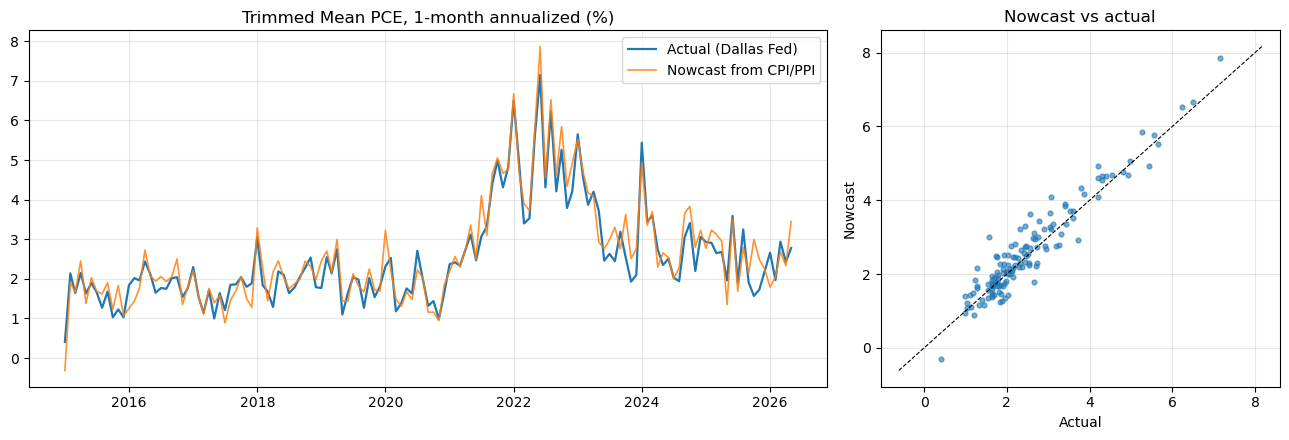

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), width_ratios=[2, 1])

ax = axes[0]
ax.plot(scored.index, scored["actual_ann"], label="Actual (Dallas Fed)", lw=1.6)
ax.plot(scored.index, scored["nowcast_ann"], label="Nowcast from CPI/PPI",
        lw=1.2, alpha=0.85)
ax.set_title("Trimmed Mean PCE, 1-month annualized (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(scored["actual_ann"], scored["nowcast_ann"], s=12, alpha=0.6)
lims = [scored[["actual_ann", "nowcast_ann"]].min().min() - 0.3,
        scored[["actual_ann", "nowcast_ann"]].max().max() + 0.3]
ax.plot(lims, lims, "k--", lw=0.8)
ax.set_xlabel("Actual")
ax.set_ylabel("Nowcast")
ax.set_title("Nowcast vs actual")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Component Diagnostics

Per-component fit of the nowcast against actual BEA changes (monthly %, x100),
weighted by average trim weight. Large `w_rmse` lines are where crosswalk refinements
would pay off most; `fb_share` is the share of months on the fallback rule.

In [13]:
window = nowcast_chg.index.intersection(price_changes.index)
err100 = (nowcast_chg.loc[window] - price_changes.loc[window]) * 100

diagnostics = pd.DataFrame({
    "source": {c: CROSSWALK[c][0] for c in component_lines},
    "mean_weight": weights.loc[window].mean(),
    "rmse": np.sqrt((err100 ** 2).mean()),
    "corr": {c: nowcast_chg.loc[window, c].corr(price_changes.loc[window, c])
             for c in component_lines},
    "fb_share": from_fallback.loc[window].mean(),
})
diagnostics["w_rmse"] = diagnostics["rmse"] * diagnostics["mean_weight"] * 100
diagnostics = diagnostics.join(
    components.set_index("line_item")["description"].str.slice(0, 45))
diagnostics = diagnostics.sort_values("w_rmse", ascending=False)
diagnostics.head(25).round(3)

,source,mean_weight,rmse,corr,fb_share,w_rmse,description
258,PPI,0.025,1.487,0.774,0.000,3.705,"Financial service charges, fees, and commissi"
342,NONE,0.030,0.630,0.282,1.000,1.889,Final consumption expenditures of nonprofit i
207,PPI,0.008,1.871,0.872,0.000,1.427,Air transportation (64)
115,CPI,0.021,0.632,0.993,0.000,1.354,Gasoline and other motor fuel
255,NONE,0.011,0.858,0.576,1.000,0.953,Commercial banks
176,PPI,0.028,0.317,0.354,0.000,0.881,Paramedical services (46)
299,CPI,0.007,1.034,0.338,0.292,0.769,Legal services
218,CPI,0.010,0.716,0.601,0.015,0.696,"Audio-video, photographic, and information pr"
50,CPI,0.009,0.729,0.944,0.015,0.661,Computer software and accessories
194,CPI,0.004,1.806,0.370,0.365,0.645,Motor vehicle leasing


## 11. Latest-Month Nowcast

The trimmed-mean index history is replicated from actual BEA data; months beyond the
latest PCE release are extended with the nowcast (using the last available weights).
The 1m/6m/12m rates below are the headline numbers. When CPI leads PCE (mid-month to
month-end), the target month has no official value yet.

In [14]:
# monthly trimmed changes: replication where BEA exists, nowcast beyond
trimmed_actual = pd.Series(
    {t: trim_one_month(price_changes.loc[t], weights.loc[t])
     for t in price_changes.index}).sort_index()

splice = trimmed_actual.copy()
for t in nowcast_index[nowcast_index > last_bea]:
    splice.loc[t] = trim_one_month(nowcast_chg.loc[t], weights.loc[last_bea])
splice = splice.sort_index()

index = pd.concat([pd.Series([100.0], index=[trimmed_actual.index[0] - pd.DateOffset(months=1)]),
                   100.0 * (1.0 + splice).cumprod()]).sort_index()

target = splice.index[-1]
rate_1m = 100 * ((index.loc[target] / index.shift(1).loc[target]) ** 12 - 1)
rate_6m = 100 * ((index.loc[target] / index.shift(6).loc[target]) ** 2 - 1)
rate_12m = 100 * (index.loc[target] / index.shift(12).loc[target] - 1)

print(f"Trimmed Mean PCE estimate for {target:%B %Y}"
      + ("  (official data not yet released)" if target > last_bea
         else "  (official data already published - shown for comparison)"))
print(f"  1-month annualized : {rate_1m:5.2f}%")
print(f"  6-month annualized : {rate_6m:5.2f}%")
print(f"  12-month           : {rate_12m:5.2f}%")
if target <= last_bea:
    print(f"  actual 1m annualized (Dallas Fed): {actual_1m.loc[target]:.2f}%")
    nc = 100 * ((1 + bt.loc[target, "nowcast"]) ** 12 - 1)
    print(f"  nowcast for same month from CPI/PPI only: {nc:.2f}%")

# largest-weight components and their estimated changes for the target month
detail = pd.DataFrame({
    "description": components.set_index("line_item")["description"].str.slice(0, 45),
    "source": {c: CROSSWALK[c][0] for c in component_lines},
    "weight": weights.loc[last_bea],
    "est_monthly_pct": nowcast_chg.loc[target] * 100,
    "on_fallback": from_fallback.loc[target],
}).sort_values("weight", ascending=False)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
bt.to_csv(OUTPUT_DIR / "nowcast_backtest.csv")
detail.to_csv(OUTPUT_DIR / "nowcast_components_latest.csv")
print(f"\nWrote {OUTPUT_DIR / 'nowcast_backtest.csv'}")
print(f"Wrote {OUTPUT_DIR / 'nowcast_components_latest.csv'}")
detail.head(15).round(4)

Trimmed Mean PCE estimate for May 2026  (official data already published - shown for comparison)
  1-month annualized :  2.78%
  6-month annualized :  2.49%
  12-month           :  2.41%
  actual 1m annualized (Dallas Fed): 2.78%
  nowcast for same month from CPI/PPI only: 3.45%

Wrote C:\Users\abour\OneDrive\Economic Research\Inflation\Trimmed Mean PCE Estimate\outputs\nowcast_backtest.csv
Wrote C:\Users\abour\OneDrive\Economic Research\Inflation\Trimmed Mean PCE Estimate\outputs\nowcast_components_latest.csv


,description,source,weight,est_monthly_pct,on_fallback
162,Owner-occupied stationary homes,CPI,0.1144,0.2968,False
184,Nonprofit hospitals' services to households,PPI,0.0519,0.3294,False
241,Other purchased meals,CPI,0.0495,0.3003,False
174,Physician services (44),PPI,0.0392,0.0649,False
157,Tenant-occupied stationary homes,CPI,0.0350,0.3619,False
176,Paramedical services (46),PPI,0.0311,0.5238,False
342,Final consumption expenditures of nonprofit i,NONE,0.0306,0.2330,True
123,Prescription drugs,CPI,0.0278,-0.8997,False
258,"Financial service charges, fees, and commissi",PPI,0.0264,6.9102,False
115,Gasoline and other motor fuel,CPI,0.0220,7.0447,False


## 12. History + Nowcast Comparison Table

One row per month from 2015 through the latest nowcast: estimated vs actual on a m/m,
1-month-annualized, and y/y basis. The y/y estimate splices each month's nowcast onto
the published index history (chained through the spliced index for months beyond the
latest PCE release, where the actual columns are blank). Full table saved to
`outputs/nowcast_vs_actual.csv`.

In [15]:
actual_12m = fred_fetch("PCETRIM12M159SFRBDAL", start="2014-01-01")

idx_act = pd.concat(
    [pd.Series([100.0], index=[trimmed_actual.index[0] - pd.DateOffset(months=1)]),
     100.0 * (1.0 + trimmed_actual).cumprod()]).sort_index()

table = pd.DataFrame(index=bt.index)
table["mm_est"] = 100 * bt["nowcast"]
table["mm_act"] = 100 * bt["replication"]
table["ann_est"] = bt["nowcast_ann"]
table["ann_act"] = bt["actual_ann"]

yoy_est = {}
for t in bt.index:
    t1 = t - pd.DateOffset(months=1)
    t12 = t - pd.DateOffset(months=12)
    if t <= last_bea:
        yoy_est[t] = 100 * (idx_act.loc[t1] * (1 + bt.loc[t, "nowcast"])
                            / idx_act.loc[t12] - 1)
    else:
        yoy_est[t] = 100 * (index.loc[t] / index.loc[t12] - 1)
table["yoy_est"] = pd.Series(yoy_est)
table["yoy_act"] = actual_12m.reindex(table.index)

table.round(3).to_csv(OUTPUT_DIR / "nowcast_vs_actual.csv")
print(f"Wrote {OUTPUT_DIR / 'nowcast_vs_actual.csv'} ({len(table)} months)")
table.tail(15).round(2)

Wrote C:\Users\abour\OneDrive\Economic Research\Inflation\Trimmed Mean PCE Estimate\outputs\nowcast_vs_actual.csv (137 months)


,mm_est,mm_act,ann_est,ann_act,yoy_est,yoy_act
date,,,,,,
2025-03-01,0.26,0.22,3.12,2.65,2.69,2.65
2025-04-01,0.24,0.22,2.95,2.68,2.66,2.64
2025-05-01,0.11,0.16,1.35,1.96,2.56,2.61
2025-06-01,0.29,0.29,3.51,3.59,2.69,2.70
2025-07-01,0.14,0.16,1.69,1.90,2.67,2.69
2025-08-01,0.23,0.27,2.79,3.25,2.76,2.80
2025-09-01,0.18,0.16,2.14,1.91,2.72,2.70
2025-10-01,0.25,0.13,2.99,1.57,2.67,2.55
2025-11-01,0.21,0.14,2.49,1.73,2.57,2.51


## 13. CPI-Only Nowcast (PPI growth carried forward)

A same-day-as-CPI variant, usable ~1 day before PPI prints: components whose BEA
deflator is a PPI (physicians, hospitals, nursing homes, airfares, insurance,
financial charges - roughly 15% of trim weight) **repeat the prior month's m/m
change** (e.g. if a component's PPI rose 0.2% in March, April is also assumed +0.2%).
CPI-mapped components and the trailing-average fallback are unchanged (both are
available on CPI day). Once PPI is released the next day, the full nowcast above
supersedes this one.

In [16]:
nowcast_cpi = pd.DataFrame(index=nowcast_index, columns=component_lines, dtype=float)
for line, (src, ids) in CROSSWALK.items():
    if src == "CPI":
        total = sum(ids.values())
        nowcast_cpi[line] = sum(source_chg[sid].reindex(nowcast_index) * (w / total)
                                for sid, w in ids.items())
    elif src == "PPI":
        total = sum(ids.values())
        combo = sum(source_chg[sid] * (w / total) for sid, w in ids.items())
        nowcast_cpi[line] = combo.shift(1).reindex(nowcast_index)  # prior month's change
nowcast_cpi = nowcast_cpi.where(~nowcast_cpi.isna(), fallback[component_lines])

bt["nowcast_cpionly"] = [
    trim_one_month(nowcast_cpi.loc[t],
                   weights.loc[t - pd.DateOffset(months=1)]
                   if t - pd.DateOffset(months=1) in weights.index
                   else weights.loc[last_bea])
    for t in bt.index]
bt["nowcast_cpionly_ann"] = 100 * ((1 + bt["nowcast_cpionly"]) ** 12 - 1)

# spliced index for y/y in months beyond the latest PCE release
splice_cpi = trimmed_actual.copy()
for t in nowcast_index[nowcast_index > last_bea]:
    splice_cpi.loc[t] = trim_one_month(nowcast_cpi.loc[t], weights.loc[last_bea])
index_cpi = pd.concat(
    [pd.Series([100.0], index=[trimmed_actual.index[0] - pd.DateOffset(months=1)]),
     100.0 * (1.0 + splice_cpi.sort_index()).cumprod()]).sort_index()

yoy_cpi = {}
for t in bt.index:
    t1 = t - pd.DateOffset(months=1)
    t12 = t - pd.DateOffset(months=12)
    if t <= last_bea:
        yoy_cpi[t] = 100 * (idx_act.loc[t1] * (1 + bt.loc[t, "nowcast_cpionly"])
                            / idx_act.loc[t12] - 1)
    else:
        yoy_cpi[t] = 100 * (index_cpi.loc[t] / index_cpi.loc[t12] - 1)
table["mm_est_cpionly"] = 100 * bt["nowcast_cpionly"]
table["ann_est_cpionly"] = bt["nowcast_cpionly_ann"]
table["yoy_est_cpionly"] = pd.Series(yoy_cpi)
table.round(3).to_csv(OUTPUT_DIR / "nowcast_vs_actual.csv")

comp = {}
for col in ["nowcast_ann", "nowcast_cpionly_ann"]:
    err = (scored.index.to_series().map(bt[col]) - scored["actual_ann"]).dropna()
    comp[col] = {"MAE": err.abs().mean(), "RMSE": np.sqrt((err ** 2).mean()),
                 "bias": err.mean(),
                 "corr": bt[col].reindex(scored.index).corr(scored["actual_ann"])}
print("CPI+PPI vs CPI-only, 1m annualized vs actual (pp):")
print(pd.DataFrame(comp).T.round(3))

target_cpi_1m = bt.loc[target, "nowcast_cpionly_ann"]
print(f"\nCPI-only estimate for {target:%B %Y}: "
      f"1m annualized {target_cpi_1m:.2f}%, y/y {yoy_cpi[target]:.2f}%")
table.tail(15)[["mm_est", "mm_est_cpionly", "mm_act",
                "ann_est", "ann_est_cpionly", "ann_act",
                "yoy_est", "yoy_est_cpionly", "yoy_act"]].round(2)

CPI+PPI vs CPI-only, 1m annualized vs actual (pp):
                       MAE   RMSE   bias   corr
nowcast_ann          0.302  0.396  0.106  0.956
nowcast_cpionly_ann  0.454  0.593  0.099  0.887

CPI-only estimate for May 2026: 1m annualized 2.79%, y/y 2.41%


,mm_est,mm_est_cpionly,mm_act,ann_est,ann_est_cpionly,ann_act,yoy_est,yoy_est_cpionly,yoy_act
date,,,,,,,,,
2025-03-01,0.26,0.28,0.22,3.12,3.36,2.65,2.69,2.71,2.65
2025-04-01,0.24,0.24,0.22,2.95,2.94,2.68,2.66,2.66,2.64
2025-05-01,0.11,0.20,0.16,1.35,2.40,1.96,2.56,2.65,2.61
2025-06-01,0.29,0.21,0.29,3.51,2.51,3.59,2.69,2.61,2.70
2025-07-01,0.14,0.19,0.16,1.69,2.30,1.90,2.67,2.72,2.69
2025-08-01,0.23,0.18,0.27,2.79,2.20,3.25,2.76,2.71,2.80
2025-09-01,0.18,0.20,0.16,2.14,2.39,1.91,2.72,2.74,2.70
2025-10-01,0.25,0.22,0.13,2.99,2.67,1.57,2.67,2.64,2.55
2025-11-01,0.21,0.22,0.14,2.49,2.68,1.73,2.57,2.59,2.51


## Caveats

- **Vintage**: CPI/PPI and BEA inputs are current-vintage (revised). Real-time accuracy
  will be modestly worse than the backtest, which measures crosswalk quality.
- **Seasonal adjustment**: NSA sources (all PPIs, some CPI items) use a crude own-history
  adjustment; BEA's internal seasonal factors differ.
- **Insurance and financial services**: PCE measures *net* insurance (premiums less
  claims) and imputed financial services; the PPI premium proxies and trailing-average
  fallbacks capture trends, not month-to-month swings. Portfolio management (line 258)
  is equity-market-driven and remains the largest single source of nowcast error.
  Note BEA's 2026 annual update replaces the portfolio-management PPI deflator with a
  quantity-extrapolation approach - watch line 258 diagnostics after that revision.
- **Structural changes**: CPI discontinued several detailed series in late 2025 (legal
  services, domestic services, household repairs); those lines now ride the fallback.
- The trim itself is forgiving: errors in small, volatile components usually land in
  the trimmed tails, which is why the aggregate tracks much better than any single
  component.